In [1]:
# Temel kütüphaneler
import pandas as pd
import numpy as np

# Görselleştirme için
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarı mesajlarını azaltmak için
import warnings
warnings.filterwarnings("ignore")

# Grafiklerin daha temiz görünmesi için
plt.style.use("default")
sns.set(rc={"figure.figsize": (10, 5)})

# Rastgelelik içeren işlemler için sabit bir seed
RANDOM_STATE = 42


In [9]:
# Veri dosyasının yolu - gerekirse değiştir
DATA_PATH = "consumer_complaints.csv" 

# CSV dosyasını oku 
df = pd.read_csv(DATA_PATH)

# İlk birkaç satıra hızlı bakış
df.head()


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473
3,08/30/2013,Student loan,Non-federal student loan,Repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,08/30/2013,Closed with explanation,Yes,Yes,510326
4,08/30/2013,Debt collection,Credit card,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,08/30/2013,Closed with explanation,Yes,Yes,511067


In [10]:
# Veri setinin boyutuna ve sütun isimlerine bakalım
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

print("\nSütun isimleri:")
for col in df.columns:
    print("-", col)



Satır sayısı: 555957
Sütun sayısı: 18

Sütun isimleri:
- date_received
- product
- sub_product
- issue
- sub_issue
- consumer_complaint_narrative
- company_public_response
- company
- state
- zipcode
- tags
- consumer_consent_provided
- submitted_via
- date_sent_to_company
- company_response_to_consumer
- timely_response
- consumer_disputed?
- complaint_id


In [11]:
# Veri tipleri ve eksik değer durumu hakkında genel fikir
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555957 entries, 0 to 555956
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date_received                 555957 non-null  object
 1   product                       555957 non-null  object
 2   sub_product                   397635 non-null  object
 3   issue                         555957 non-null  object
 4   sub_issue                     212622 non-null  object
 5   consumer_complaint_narrative  66806 non-null   object
 6   company_public_response       85124 non-null   object
 7   company                       555957 non-null  object
 8   state                         551070 non-null  object
 9   zipcode                       551452 non-null  object
 10  tags                          77959 non-null   object
 11  consumer_consent_provided     123458 non-null  object
 12  submitted_via                 555957 non-null  object
 13 

In [12]:
# Eğer 'consumer_disputed?' yoksa 'consumer_disputed' olarak değiştir.
target_col = "consumer_disputed?"  # gerekirse burayı değiştir

if target_col not in df.columns:
    raise ValueError(f"Hedef sütun '{target_col}' bulunamadı. "
                     f"Lütfen df.columns çıktısına bakıp ismi güncelle.")

print("Hedef sütun:", target_col)
print("\nSınıf dağılımı (adet):")
print(df[target_col].value_counts(dropna=False))

print("\nSınıf dağılımı (yüzde):")
print((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2))


Hedef sütun: consumer_disputed?

Sınıf dağılımı (adet):
consumer_disputed?
No     443823
Yes    112134
Name: count, dtype: int64

Sınıf dağılımı (yüzde):
consumer_disputed?
No     79.83
Yes    20.17
Name: proportion, dtype: float64


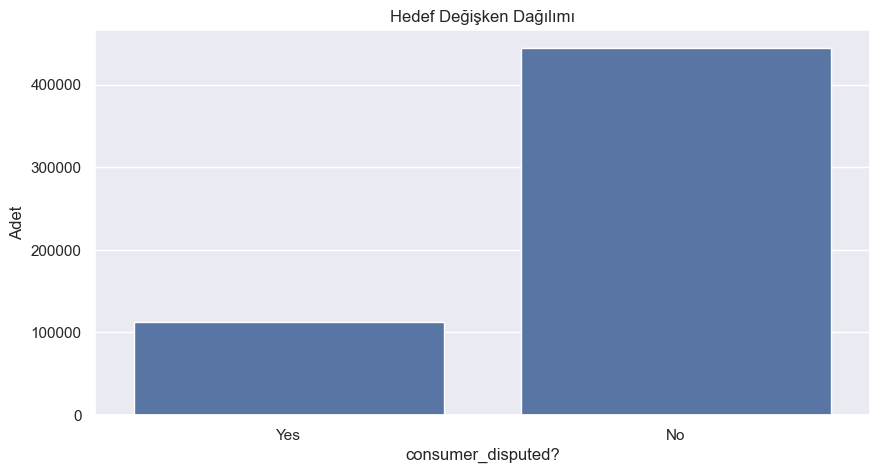

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=target_col, data=df)
plt.title("Hedef Değişken Dağılımı")
plt.xlabel(target_col)
plt.ylabel("Adet")
plt.show()


In [14]:
 # Eksik değer sayıları
missing_counts = df.isnull().sum().sort_values(ascending=False)
print("Eksik değer sayıları (ilk 20):")
print(missing_counts.head(20))


Eksik değer sayıları (ilk 20):
consumer_complaint_narrative    489151
tags                            477998
company_public_response         470833
consumer_consent_provided       432499
sub_issue                       343335
sub_product                     158322
state                             4887
zipcode                           4505
date_sent_to_company                 0
consumer_disputed?                   0
timely_response                      0
company_response_to_consumer         0
date_received                        0
submitted_via                        0
product                              0
company                              0
issue                                0
complaint_id                         0
dtype: int64


In [15]:
# Eksik değer oranları (yüzde)
missing_ratio = (df.isnull().mean() * 100).sort_values(ascending=False)
print("Eksik değer oranları (ilk 20):")
print(missing_ratio.head(20).round(2))


Eksik değer oranları (ilk 20):
consumer_complaint_narrative    87.98
tags                            85.98
company_public_response         84.69
consumer_consent_provided       77.79
sub_issue                       61.76
sub_product                     28.48
state                            0.88
zipcode                          0.81
date_sent_to_company             0.00
consumer_disputed?               0.00
timely_response                  0.00
company_response_to_consumer     0.00
date_received                    0.00
submitted_via                    0.00
product                          0.00
company                          0.00
issue                            0.00
complaint_id                     0.00
dtype: float64


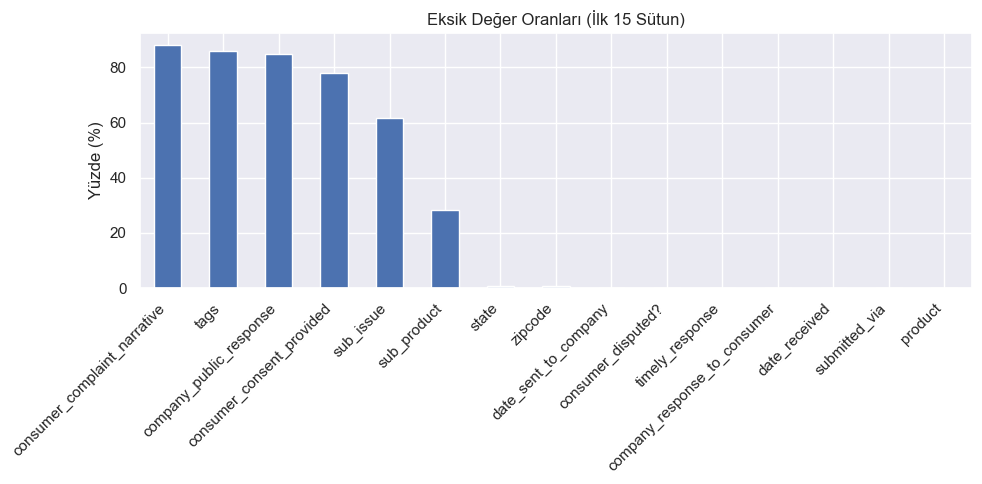

In [16]:
# Eksik değer oranlarını bar grafikte göstermek
missing_ratio.head(15).plot(kind="bar")
plt.title("Eksik Değer Oranları (İlk 15 Sütun)")
plt.ylabel("Yüzde (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


product
Mortgage                   186475
Debt collection            101052
Credit reporting            91854
Credit card                 66468
Bank account or service     62563
Consumer Loan               20990
Student loan                15839
Payday loan                  3877
Money transfers              3812
Prepaid card                 2470
Name: count, dtype: int64


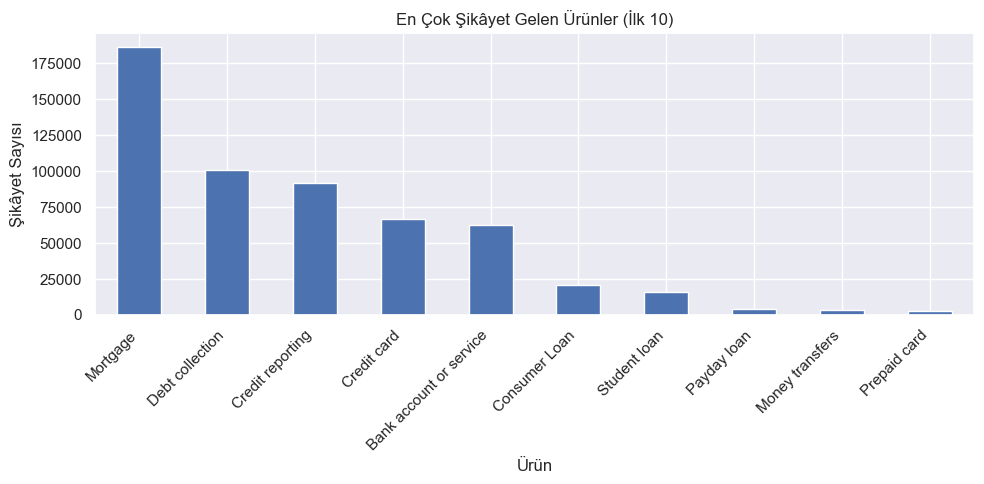

In [17]:
# En çok şikâyet gelen ilk 10 ürün
product_counts = df["product"].value_counts().head(10)

print(product_counts)

product_counts.plot(kind="bar")
plt.title("En Çok Şikâyet Gelen Ürünler (İlk 10)")
plt.ylabel("Şikâyet Sayısı")
plt.xlabel("Ürün")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [18]:
# Şikâyet metni sütunu varsa uzunluk özellikleri üretelim
text_col = "consumer_complaint_narrative"

if text_col in df.columns:
    # Eksik değerleri boş string yapıyoruz
    df[text_col] = df[text_col].fillna("")
    
    # Karakter ve kelime sayısı
    df["complaint_length_chars"] = df[text_col].str.len()
    df["complaint_length_words"] = df[text_col].str.split().apply(len)
    
    print(df[["complaint_length_chars", "complaint_length_words"]].describe().T)
else:
    print(f"{text_col} sütunu bulunamadı.")


                           count        mean         std  min  25%  50%  75%  \
complaint_length_chars  555957.0  124.920940  462.414115  0.0  0.0  0.0  0.0   
complaint_length_words  555957.0   22.908541   84.776148  0.0  0.0  0.0  0.0   

                           max  
complaint_length_chars  5153.0  
complaint_length_words  1284.0  


In [19]:
# Tarih sütunlarından yanıt süresini hesaplayalım
df["date_received"] = pd.to_datetime(df["date_received"], errors="coerce")
df["date_sent_to_company"] = pd.to_datetime(df["date_sent_to_company"], errors="coerce")

df["response_days"] = (df["date_sent_to_company"] - df["date_received"]).dt.days

df["response_days"].describe()


count    555957.000000
mean          4.657344
std          17.200280
min          -1.000000
25%           0.000000
50%           1.000000
75%           4.000000
max         993.000000
Name: response_days, dtype: float64

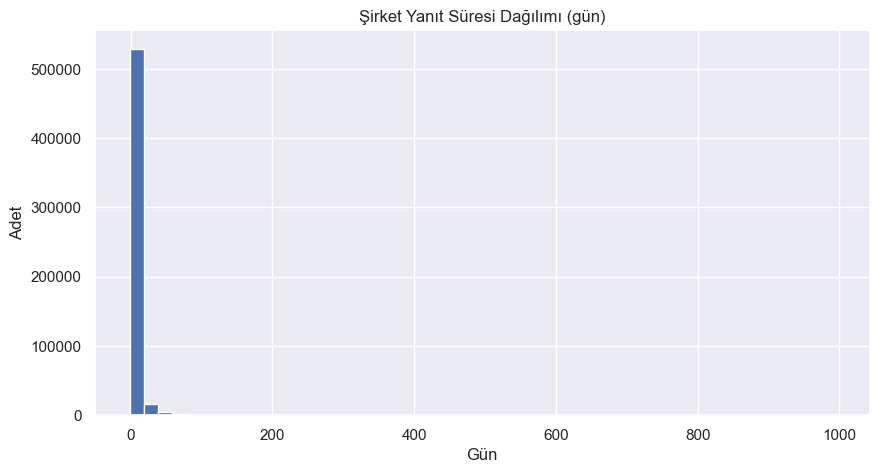

In [20]:
df["response_days"].hist(bins=50)
plt.title("Şirket Yanıt Süresi Dağılımı (gün)")
plt.xlabel("Gün")
plt.ylabel("Adet")
plt.show()


In [21]:
from sklearn.model_selection import train_test_split

# Hedef sütun zaten consumer_disputed? olarak net
target_col = "consumer_disputed?"

# Yes -> 1, No -> 0
y = df[target_col].map({"Yes": 1, "No": 0})

print("Pozitif sınıf (1) oranı:", y.mean())


Pozitif sınıf (1) oranı: 0.20169545486431503


In [22]:
# Kullanmak istediğimiz temel sütunlar
base_features = [
    "product",
    "issue",
    "company_response_to_consumer",
    "timely_response",
    "complaint_length_words",
    "response_days"
]

# Bu sütunlardan hangileri gerçekten mevcut diye kontrol edelim
available_features = [col for col in base_features if col in df.columns]

print("Kullanılacak özellikler:")
print(available_features)

X = df[available_features].copy()


Kullanılacak özellikler:
['product', 'issue', 'company_response_to_consumer', 'timely_response', 'complaint_length_words', 'response_days']


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline  

# Kategorik ve sayısal sütunları ayıralım
categorical_cols = [col for col in X.columns if X[col].dtype == "object"]
numeric_cols = [col for col in X.columns if X[col].dtype != "object"]

print("Kategorik sütunlar:", categorical_cols)
print("Sayısal sütunlar:", numeric_cols)

# Sayısal sütunlar için medyan ile doldurma
numeric_transformer = SimpleImputer(strategy="median")

# Kategorik sütunlar için en sık değer + One-Hot Encoding
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# İki tür dönüşümü birleştiren ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


Kategorik sütunlar: ['product', 'issue', 'company_response_to_consumer', 'timely_response']
Sayısal sütunlar: ['complaint_length_words', 'response_days']


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Eğitim kümesi boyutu:", X_train.shape)
print("Test kümesi boyutu:", X_test.shape)


Eğitim kümesi boyutu: (444765, 6)
Test kümesi boyutu: (111192, 6)


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression için pipeline
log_reg_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,          # iterasyon sayısını artırdık
            class_weight="balanced",# sınıf dengesizliğini telafi etmek için
            n_jobs=-1               # mümkünse tüm çekirdekleri kullan
        ))
    ]
)

# Modeli eğit
log_reg_clf.fit(X_train, y_train)

# Test kümesi üzerinde tahminler
y_pred_lr = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Sonuçları ===")
print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))


=== Logistic Regression Sonuçları ===
              precision    recall  f1-score   support

           0     0.8581    0.4694    0.6068     88765
           1     0.2480    0.6927    0.3653     22427

    accuracy                         0.5144    111192
   macro avg     0.5530    0.5810    0.4860    111192
weighted avg     0.7350    0.5144    0.5581    111192

ROC AUC: 0.6091869651377171


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Decision Tree için pipeline
dt_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=8,           # ağacın derinliğini sınırlıyoruz
            min_samples_split=50,  # çok küçük yaprakları engellemek için
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]
)

# Modeli eğit
dt_clf.fit(X_train, y_train)

# Test kümesi üzerinde tahminler
y_pred_dt = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]

print("=== Decision Tree Sonuçları ===")
print(classification_report(y_test, y_pred_dt, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))


=== Decision Tree Sonuçları ===
              precision    recall  f1-score   support

           0     0.8670    0.3975    0.5451     88765
           1     0.2414    0.7587    0.3662     22427

    accuracy                         0.4703    111192
   macro avg     0.5542    0.5781    0.4556    111192
weighted avg     0.7408    0.4703    0.5090    111192

ROC AUC: 0.5992381699289502


In [33]:
from sklearn.metrics import accuracy_score

results = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt)
    ]
}

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,ROC AUC
0,Logistic Regression,0.514399,0.609187
1,Decision Tree,0.470322,0.599238


In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Dummy model: her zaman en sık görülen sınıfı (No) tahmin ediyor
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_test)

# ROC AUC için predict_proba gerekiyor (most_frequent de üretebiliyor)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

print("=== DummyClassifier (most_frequent) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dummy))
print(classification_report(y_test, y_pred_dummy, digits=4))


=== DummyClassifier (most_frequent) ===
Accuracy: 0.7983038348082596
ROC AUC: 0.5
              precision    recall  f1-score   support

           0     0.7983    1.0000    0.8878     88765
           1     0.0000    0.0000    0.0000     22427

    accuracy                         0.7983    111192
   macro avg     0.3992    0.5000    0.4439    111192
weighted avg     0.6373    0.7983    0.7088    111192



In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_unbalanced_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            n_jobs=-1
            # class_weight vermiyoruz
        ))
    ]
)

log_reg_unbalanced_clf.fit(X_train, y_train)

y_pred_lr_unb = log_reg_unbalanced_clf.predict(X_test)
y_proba_lr_unb = log_reg_unbalanced_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (class_weight yok) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_unb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr_unb))
print(classification_report(y_test, y_pred_lr_unb, digits=4))


=== Logistic Regression (class_weight yok) ===
Accuracy: 0.7983038348082596
ROC AUC: 0.6092738371742838
              precision    recall  f1-score   support

           0     0.7983    1.0000    0.8878     88765
           1     0.0000    0.0000    0.0000     22427

    accuracy                         0.7983    111192
   macro avg     0.3992    0.5000    0.4439    111192
weighted avg     0.6373    0.7983    0.7088    111192



In [37]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

metrics = []

def add_row(name, y_true, y_pred, y_proba):
    # Pozitif sınıf (1) için recall'ı da ekleyelim
    from sklearn.metrics import recall_score
    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba),
        "Recall (Yes)": recall_score(y_true, y_pred, pos_label=1)
    })

add_row("Dummy (most_frequent)", y_test, y_pred_dummy, y_proba_dummy)
add_row("LogReg (no class_weight)", y_test, y_pred_lr_unb, y_proba_lr_unb)
add_row("LogReg (class_weight=balanced)", y_test, y_pred_lr, y_proba_lr)
add_row("Decision Tree (class_weight=balanced)", y_test, y_pred_dt, y_proba_dt)

results_all = pd.DataFrame(metrics)
results_all


,Model,Accuracy,ROC AUC,Recall (Yes)
0,Dummy (most_frequent),0.798304,0.500000,0.000000
1,LogReg (no class_weight),0.798304,0.609274,0.000000
2,LogReg (class_weight=balanced),0.514399,0.609187,0.692692
3,Decision Tree (class_weight=balanced),0.470322,0.599238,0.758728


In [38]:
# Özellik seçimi (feature selection) + Logistic Regression
# Burada amaç: One-Hot sonrası oluşan yüksek boyutlu uzaydan
# sınıflandırma için en anlamlı K özelliği seçmek.

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Feature selection + Logistic Regression pipeline'ı
log_reg_fs_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),                      # Daha önce tanımladığımız ön işleme
        ("feature_select", SelectKBest(f_classif, k=100)), # En iyi 100 özelliği seç
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

# Modeli eğitiyoruz
log_reg_fs_clf.fit(X_train, y_train)

# Test kümesi üzerinde tahminler
y_pred_lr_fs = log_reg_fs_clf.predict(X_test)
y_proba_lr_fs = log_reg_fs_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression + SelectKBest Sonuçları ===")
print(classification_report(y_test, y_pred_lr_fs, digits=4))

acc_lr_fs = accuracy_score(y_test, y_pred_lr_fs)
roc_lr_fs = roc_auc_score(y_test, y_proba_lr_fs)
print("Accuracy:", acc_lr_fs)
print("ROC AUC:", roc_lr_fs)


=== Logistic Regression + SelectKBest Sonuçları ===
              precision    recall  f1-score   support

           0     0.8579    0.4700    0.6073     88765
           1     0.2480    0.6919    0.3652     22427

    accuracy                         0.5147    111192
   macro avg     0.5530    0.5809    0.4862    111192
weighted avg     0.7349    0.5147    0.5584    111192

Accuracy: 0.5147312756313404
ROC AUC: 0.6088614724110204


In [41]:
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

acc_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_proba_lr)

acc_lr_fs = accuracy_score(y_test, y_pred_lr_fs)
roc_lr_fs = roc_auc_score(y_test, y_proba_lr_fs)

comparison_lr = pd.DataFrame({
    "Versiyon": ["Önce (FS yok)", "Sonra (SelectKBest k=100)"],
    "Accuracy": [acc_lr, acc_lr_fs],
    "ROC AUC": [roc_lr, roc_lr_fs]
})

comparison_lr


,Versiyon,Accuracy,ROC AUC
0,Önce (FS yok),0.514399,0.609187
1,Sonra (SelectKBest k=100),0.514731,0.608861
